<h1>Predobrada dermatoloških slika</h1>

<p>Prateći notebook uz seminarski rad, u kome se demonstriraju tehnike o kojima je bilo reči u radu: kako kvalitet slike (šum, zamućenje, slab kontrast, artefakti) utiče na klasifikaciju, i koliko predobrada i augmentacija mogu da poprave (ili pokvare) rezultat. </p>
<p>Koriste se tri datoteke iz skupa:</p>
<ul>
<li><code>HAM10000_metadata.csv</code> — 10.015 redova sa oznakama (dx), načinom verifikacije (dx_type) i metapodacima (uzrast, pol, lokalizacija). Osnova za EDA.</li>
<li><code>hmnist_28_28_RGB.csv</code> — iste lezije kao 28×28 RGB slike (2352 piksela + label). Na njima radimo predobradu i klasifikaciju.</li>
<li><code>ISIC_0024306.jpg</code> — jedna slika u punoj rezoluciji (600×450), za demonstraciju artefakata (dlake, segmentacija) gde je 28×28 premalo.</li>
</ul>


<h1>1 Podešavanje i biblioteke </h1>

In [1]:
import time, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2
from scipy.ndimage import gaussian_filter

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, classification_report)

In [2]:
RS = 42
np.random.seed(RS)
plt.rcParams["figure.figsize"] = (10, 6)

DATA = os.environ.get("HAM_DATA", "./Data")
META_CSV  = f"{DATA}/HAM10000_metadata.csv"
PIXEL_CSV = f"{DATA}/hmnist_28_28_RGB.csv"
SAMPLE_IMG = f"{DATA}/ISIC_0024306.jpg"

In [3]:
LABELS = ["akiec", "bcc", "bkl", "df", "nv", "vasc", "mel"]
FULL = {
    "akiec": "Aktinicna keratoza / Bowen (akiec)",
    "bcc":   "Bazocelularni karcinom (bcc)",
    "bkl":   "Benigna keratoza (bkl)",
    "df":    "Dermatofibrom (df)",
    "nv":    "Melanocitni nevus (nv)",
    "vasc":  "Vaskularne lezije (vasc)",
    "mel":   "Melanom (mel)",
}

<h1>2 Učitavanje i EDA metapodataka</h1>
<p>Pre slika, obradjuje se tabela metapodataka. Ona otkriva najvažnije osobine skupa koje će kasnije diktirati predobradu</p>

In [4]:
meta = pd.read_csv(META_CSV)
print("oblik:", meta.shape)
meta.head()

oblik: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [5]:
meta.info()

<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
dtypes: float64(1), str(6)
memory usage: 547.8 KB


<h2>2.1 Raspodela klasa</h2>


In [6]:
counts = meta.dx.value_counts()
perc = (counts / counts.sum() * 100).round(1)
dist = pd.DataFrame({"broj": counts, "udeo_%": perc, "pun_naziv": [FULL[d] for d in counts.index]})
dist

,broj,udeo_%,pun_naziv
dx,,,
nv,6705,66.9,Melanocitni nevus (nv)
mel,1113,11.1,Melanom (mel)
bkl,1099,11.0,Benigna keratoza (bkl)
bcc,514,5.1,Bazocelularni karcinom (bcc)
akiec,327,3.3,Aktinicna keratoza / Bowen (akiec)
vasc,142,1.4,Vaskularne lezije (vasc)
df,115,1.1,Dermatofibrom (df)


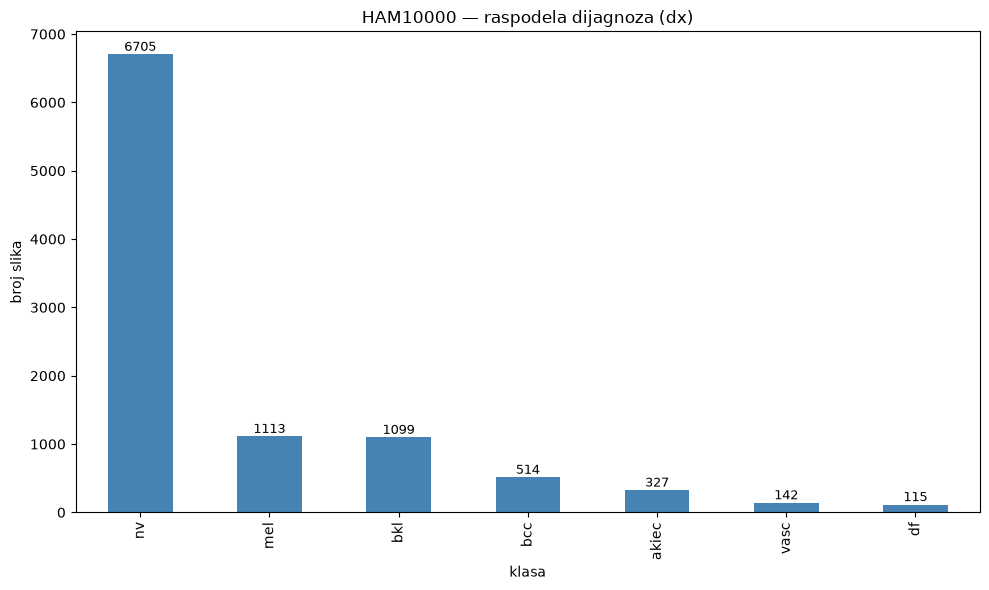

In [7]:
ax = counts.plot(kind="bar", color="steelblue")
ax.set_title("HAM10000 — raspodela dijagnoza (dx)"); ax.set_xlabel("klasa"); ax.set_ylabel("broj slika")
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha="center", fontsize=9)
plt.tight_layout(); plt.show()

<p>Klasa <b>nv (melanocitni nevus)</b> ima 6705 slika (preko 66% skupa) dok najređa klasa <b>df (dermatofibrom)</b> ima svega 115 (oko 1.1%). Odnos najčešće i najređe klase je oko <b>58:1</b>. Ovo je ključni problem: model koji uvek predviđa <code>nv</code> postiže oko 67% tačnosti ne naučivši ništa. Zato tačnost (accuracy) ovde vara, a pravu sliku daju <b>balanced accuracy</b> i <b>macro-F1</b>, koje jednako tretiraju sve klase. Klinički je najopasnije prevideti <b>mel (melanom)</b>, koji je takođe manjinska klasa.</p>

<h2>2.2 Način verifikacije dijagnoze (dx_type)</h2>
<p>HAM10000 dijagnoze nisu sve jednako pouzdane, zavise od načina potvrde.</p>

In [8]:
vt = meta.dx_type.value_counts()
vtp = (vt/vt.sum()*100).round(1)
pd.DataFrame({"broj": vt, "udeo_%": vtp})

,broj,udeo_%
dx_type,,
histo,5340,53.3
follow_up,3704,37.0
consensus,902,9.0
confocal,69,0.7


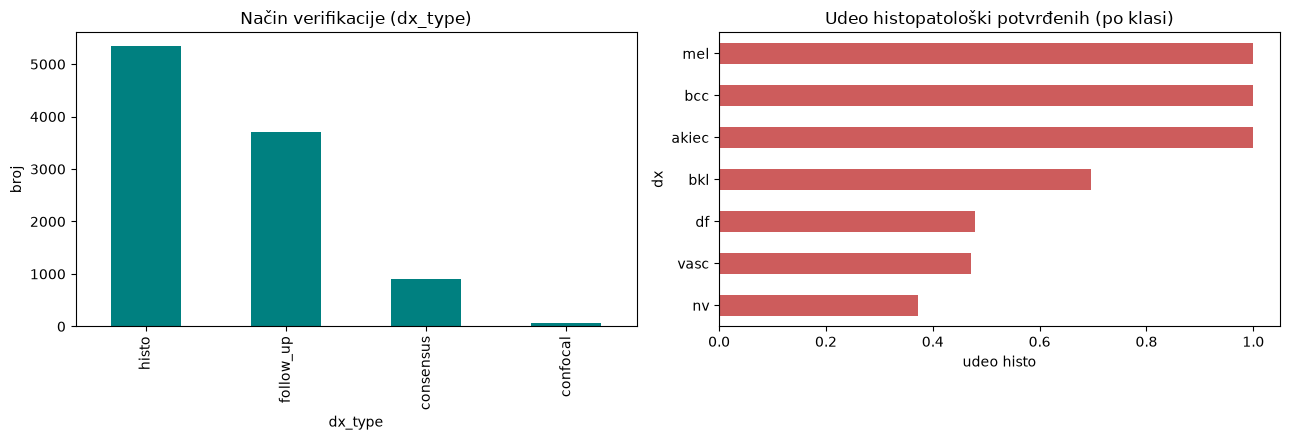

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
meta.dx_type.value_counts().plot(kind="bar", ax=ax[0], color="teal")
ax[0].set_title("Način verifikacije (dx_type)"); ax[0].set_ylabel("broj")
# udeo histo verifikacije po klasi
ct = pd.crosstab(meta.dx, meta.dx_type, normalize="index")["histo"].sort_values()
ct.plot(kind="barh", ax=ax[1], color="indianred")
ax[1].set_title("Udeo histopatološki potvrđenih (po klasi)"); ax[1].set_xlabel("udeo histo")
plt.tight_layout(); plt.show()

<p>Oko 53% dijagnoza je <b>histopatološki</b> potvrđeno (najpouzdanije), a značajan deo počiva na <b>follow-up</b> praćenju ili stručnom <b>consensus</b>-u. Maligne klase (mel, bcc, akiec) gotovo su uvek histološki potvrđene, dok je kod benignih nevusa (nv) veliki deo potvrđen samo praćenjem, što je razumno klinički, ali znači da oznake nisu uniformnog kvaliteta.</p>

<h2>2.3 Uzrast, pol i lokalizacija</h2>

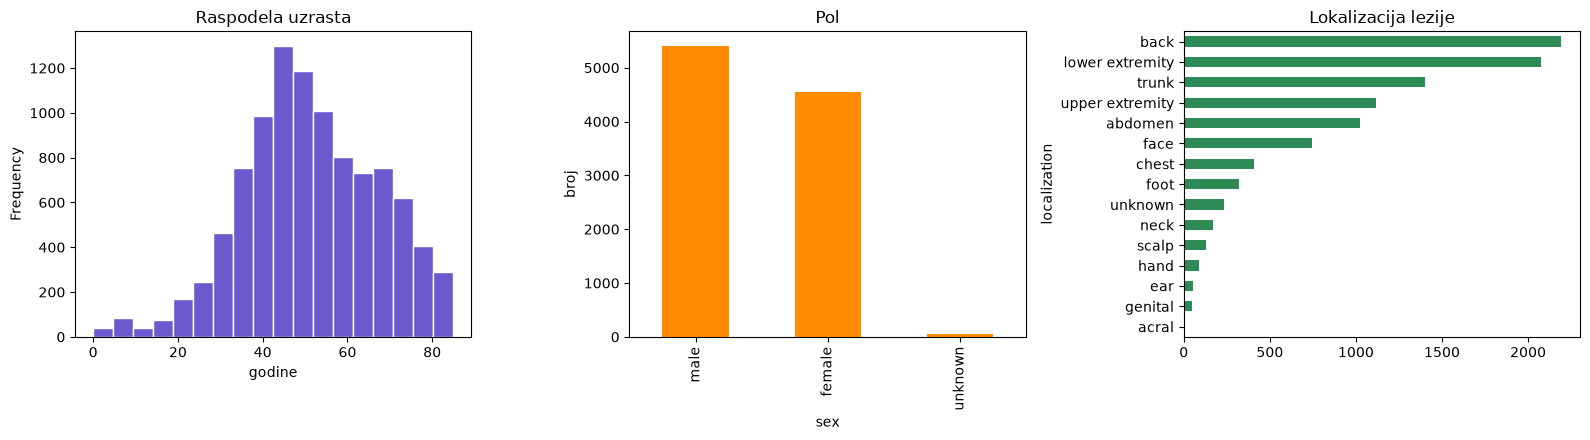

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
meta.age.dropna().plot(kind="hist", bins=18, ax=ax[0], color="slateblue", edgecolor="white")
ax[0].set_title("Raspodela uzrasta"); ax[0].set_xlabel("godine")
meta.sex.value_counts().plot(kind="bar", ax=ax[1], color="darkorange")
ax[1].set_title("Pol"); ax[1].set_ylabel("broj")
meta.localization.value_counts().plot(kind="barh", ax=ax[2], color="seagreen")
ax[2].set_title("Lokalizacija lezije"); ax[2].invert_yaxis()
plt.tight_layout(); plt.show()

In [11]:
print("uzrast: prosek = %.1f, opseg = %.0f-%.0f, nedostaje = %d" % (
      meta.age.mean(), meta.age.min(), meta.age.max(), meta.age.isna().sum()))
print("pol 'unknown':", int((meta.sex == 'unknown').sum()))

uzrast: prosek = 51.9, opseg = 0-85, nedostaje = 57
pol 'unknown': 57


<h2>2.4 Duplikati lezija (lesion_id)</h2>
<p>Važan, lako previđen detalj: ista lezija ume da ima više slika. To znači da slučajna podela train/test može da <b>iscuri</b> (data leakage).</p>

In [12]:
print("redova (slika):", len(meta))
print("jedinstvenih lezija:", meta.lesion_id.nunique())
per = meta.groupby("lesion_id").size().value_counts().sort_index()
print("\nslika po leziji:")
print(per)

redova (slika): 10015
jedinstvenih lezija: 7470

slika po leziji:
1    5514
2    1423
3     490
4      34
5       5
6       4
Name: count, dtype: int64


<p>Od 10.015 slika ima samo <b>7470 jedinstvenih lezija</b>, gotovo 25% su dodatne slike postojećih lezija.

<h1>3 Učitavanje slika (pixel CSV)</h1>
<p><code>hmnist_28_28_RGB.csv</code> ima po jednoj liniji za svaku leziju, 2352 vrednosti piksela (28×28×3) i kolonu <code>label</code>.</p>

In [13]:
t = time.time()
NPY_X, NPY_Y = f"{DATA}/X_all.npy", f"{DATA}/y_all.npy"
if os.path.exists(NPY_X):                       # brzo: keširani niz
    X_all = np.load(NPY_X); y_all = np.load(NPY_Y)
else:                                           # prvi put: čita CSV pa kešira
    px = pd.read_csv(PIXEL_CSV)
    X_all = px.drop(columns=["label"]).values.astype(np.uint8).reshape(-1, 28, 28, 3)
    y_all = px["label"].values
    np.save(NPY_X, X_all); np.save(NPY_Y, y_all)
print("učitano:", X_all.shape, "za %.1f s" % (time.time()-t))
print("X opseg:", X_all.min(), "-", X_all.max())
print("y:", dict(zip(LABELS, np.bincount(y_all))))

učitano: (10015, 28, 28, 3) za 0.0 s
X opseg: 0 - 255
y: {'akiec': np.int64(327), 'bcc': np.int64(514), 'bkl': np.int64(1099), 'df': np.int64(115), 'nv': np.int64(6705), 'vasc': np.int64(142), 'mel': np.int64(1113)}


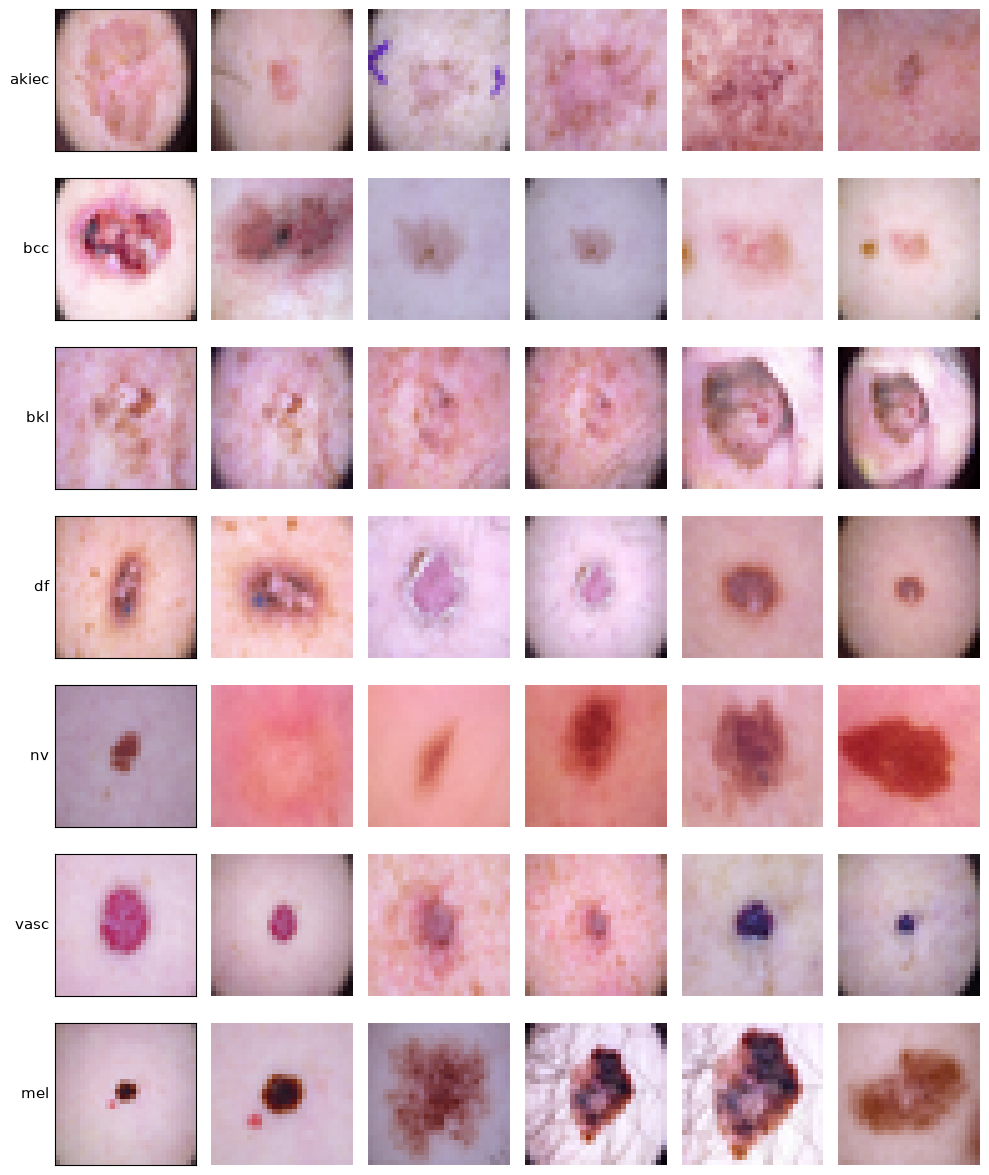

In [14]:
fig, axes = plt.subplots(7, 6, figsize=(10, 12))
for r, lab in enumerate(range(7)):
    idx = np.where(y_all == lab)[0][:6]
    for c, i in enumerate(idx):
        axes[r, c].imshow(X_all[i]); axes[r, c].axis("off")
    axes[r, 0].set_ylabel(LABELS[lab], rotation=0, ha="right", va="center", fontsize=11)
    axes[r, 0].axis("on"); axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
plt.tight_layout()
plt.show()

<h2>3.2 Prosečna slika i varijabilnost po klasi</h2>

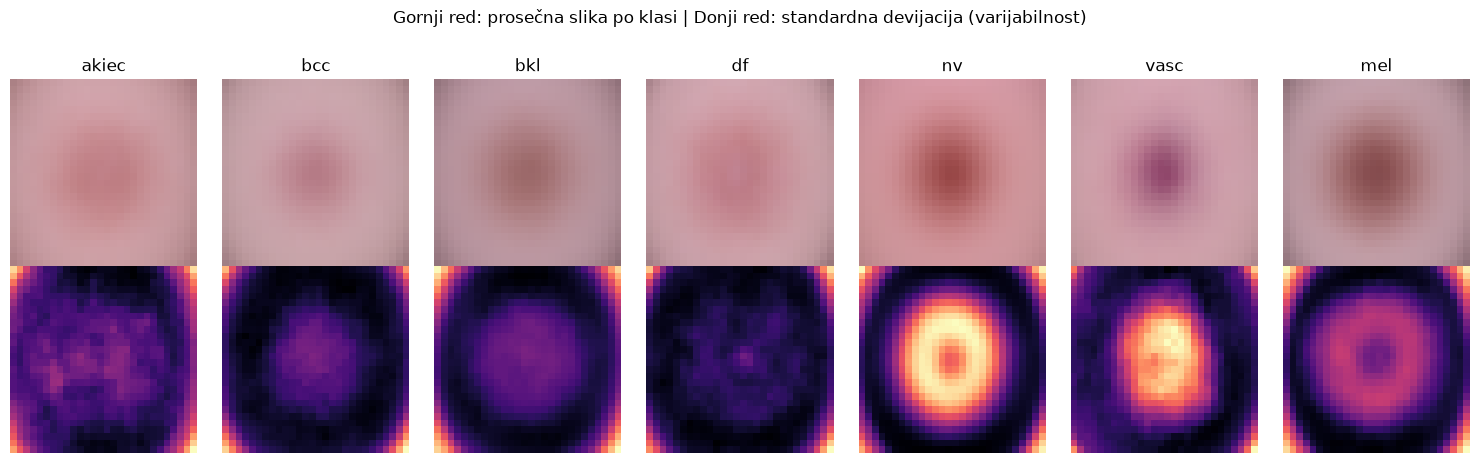

In [15]:
fig, axes = plt.subplots(2, 7, figsize=(15, 4.5))
for c, lab in enumerate(range(7)):
    grp = X_all[y_all == lab].astype(np.float32)
    axes[0, c].imshow(grp.mean(0).astype(np.uint8)); axes[0, c].set_title(LABELS[lab]); axes[0, c].axis("off")
    axes[1, c].imshow(grp.std(0).mean(2), cmap="magma"); axes[1, c].axis("off")
axes[0, 0].set_ylabel("prosek", rotation=0, ha="right"); 
axes[1, 0].set_ylabel("std", rotation=0, ha="right")
plt.suptitle("Gornji red: prosečna slika po klasi | Donji red: standardna devijacija (varijabilnost)", y=1.02)
plt.tight_layout(); plt.show()

<p>Prosečne slike potvrđuju da je centar kadra po pravilu lezija (tamnija mrlja na svetlijoj koži), a mapa standardne devijacije pokazuje gde su klase najraznovrsnije (obično po obodu, gde se javljaju artefakti i varijacije kože).</p>

<h1>4 Pomoćne funkcije</h1>
<p>DFiksiraju se dva modela i jedinstvena procedura evaluacije. Koriste se <b>poduzorak</b> od 1500 slika; raspodela klasa ostaje ista, pa zaključci o <i>relativnom</i> efektu predobrade važe. Jednom (sekcija 5) se pokazuje i baseline na celom skupu radi poređenja.</p>

In [16]:
def to_X(a):
    """(n,H,W,3) uint8 -> (n, H*W*3) float u [0,1]."""
    return a.reshape(len(a), -1).astype(np.float32) / 255.0

In [17]:
def make_models():
    return {
        "SVM":  SVC(kernel="rbf", C=10, gamma="scale", random_state=RS),
        "k-NN": KNeighborsClassifier(n_neighbors=5),
    }

In [18]:
results = []

def evaluate(experiment, technique, Xtr, Xte, ytr, yte):
    for name, model in make_models().items():
        t0 = time.perf_counter(); model.fit(to_X(Xtr), ytr);        fit_t  = time.perf_counter()-t0
        t0 = time.perf_counter(); pred = model.predict(to_X(Xte));  pred_t = time.perf_counter()-t0
        results.append({
            "experiment": experiment, "technique": technique, "model": name,
            "accuracy":     round(accuracy_score(yte, pred), 4),
            "balanced_acc": round(balanced_accuracy_score(yte, pred), 4),
            "macro_f1":     round(f1_score(yte, pred, average="macro"), 4),
            "fit_s":        round(fit_t, 2),
        })
    return pred 

In [19]:
def summary(experiment, metric="macro_f1"):
    s = pd.DataFrame(results)
    s = s[s.experiment == experiment]
    piv = s.pivot(index="technique", columns="model", values=metric)
    if "baseline" in piv.index:
        for m in piv.columns:
            piv[f"{m} Δ"] = (piv[m] - piv.loc["baseline", m]).round(4)
    return piv

In [20]:
def show_grid(images, titles, ncols=4, size=2.6, cmap=None):
    n = len(images); nrows = int(np.ceil(n/ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*size, nrows*size))
    axes = np.array(axes).reshape(-1)
    for ax, im, t in zip(axes, images, titles):
        gray = (im.ndim == 2)
        ax.imshow(im, cmap=(cmap or ('gray' if gray else None)),
                  vmin=0, vmax=(1 if im.max() <= 1.01 else 255))
        ax.set_title(t, fontsize=9); ax.axis("off")
    for ax in axes[n:]: ax.axis("off")
    plt.tight_layout(); plt.show()

In [21]:
rng = np.random.RandomState(RS)
sub = rng.choice(len(X_all), 1500, replace=False)
Xs, ys = X_all[sub], y_all[sub]
Xtr, Xte, ytr, yte = train_test_split(Xs, ys, test_size=0.25, stratify=ys, random_state=RS)
print("train:", Xtr.shape, "| test:", Xte.shape)
print("train balans:", dict(zip(LABELS, np.bincount(ytr, minlength=7))))

train: (1125, 28, 28, 3) | test: (375, 28, 28, 3)
train balans: {'akiec': np.int64(41), 'bcc': np.int64(48), 'bkl': np.int64(132), 'df': np.int64(15), 'nv': np.int64(747), 'vasc': np.int64(14), 'mel': np.int64(128)}


<h1>5 Baseline </h1>
<p>Polazna tačka: sirovi pikseli, bez ikakve predobrade.</p>

In [22]:
evaluate("clean", "baseline", Xtr, Xte, ytr, yte)
pd.DataFrame(results).query("experiment=='clean' and technique=='baseline'")

,experiment,technique,model,accuracy,balanced_acc,macro_f1,fit_s
0,clean,baseline,SVM,0.7333,0.2913,0.3145,0.23
1,clean,baseline,k-NN,0.6800,0.2173,0.2175,0.00


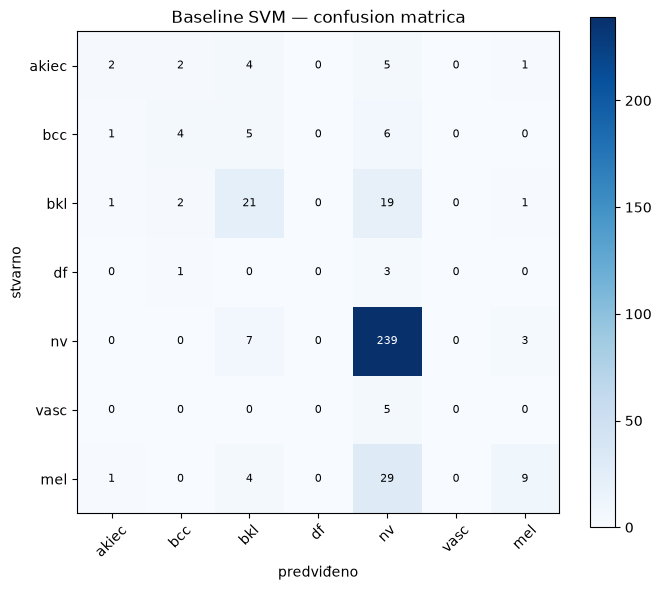

In [23]:
m = SVC(kernel="rbf", C=10, gamma="scale", random_state=RS).fit(to_X(Xtr), ytr)
pred = m.predict(to_X(Xte))
cm = confusion_matrix(yte, pred)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(7)); ax.set_xticklabels(LABELS, rotation=45)
ax.set_yticks(range(7)); ax.set_yticklabels(LABELS)
ax.set_xlabel("predviđeno"); ax.set_ylabel("stvarno"); ax.set_title("Baseline SVM — confusion matrica")
for i in range(7):
    for j in range(7):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=8)
plt.colorbar(im); plt.tight_layout(); plt.show()

<p>Confusion matrica otkriva problem: skoro sve klase se klasifikuju kao <code>nv</code>. Model maksimizuje tačnost tako što retke klase proglašava za najčešću. Otud visok <b>accuracy</b> (~72%) ali niska <b>balanced accuracy</b> i <b>macro-F1</b> (~30–35%). Klinički je to loše: melanomi (mel) se previde. Zato ce se u nastavku koristiti prevashodno macro-F1 i balanced accuracy.</p>

In [24]:
from sklearn.dummy import DummyClassifier
dum = DummyClassifier(strategy="most_frequent").fit(to_X(Xtr), ytr)
pd_ = dum.predict(to_X(Xte))
print("Uvek-nv klasifikator:")
print("  accuracy     :", round(accuracy_score(yte, pd_), 4))
print("  balanced_acc :", round(balanced_accuracy_score(yte, pd_), 4))
print("  macro_f1     :", round(float(f1_score(yte, pd_, average='macro')), 4))

Uvek-nv klasifikator:
  accuracy     : 0.664
  balanced_acc : 0.1429
  macro_f1     : 0.114


<p>Trivijalni klasifikator koji <b>uvek predviđa nv</b> postiže ~67% tačnosti, ali balanced accuracy od svega ~14% (1/7) i loš macro-F1. To je donja granica koju svaki ozbiljan model mora da nadmaši po balansiranim metrikama, a ne po tačnosti. Baseline SVM ima visoku tačnost ali i dalje nisku balanced accuracy, vuče ga ista neravnoteža. Više podataka (ceo skup od 10k) podiže tačnost, ali <b>ne rešava neuravnoteženost</b> </p>

<h1>6 Kvalitet slike: degradacija i oporavak</h1>
<p>Simuliranje problema kvaliteta iz sekcije 3 rada (šum, zamućenje) i primenjivanje odgovarajuće predobrade. Sve degradacije se primenjuju i na train i na test.</p>

<h2>6.1 Gaussov šum i uklanjanje šuma</h2>
<p><b>Gaussov šum</b> dodaje svakom pikselu slučajnu vrednost iz normalne raspodele. Uklanjamo ga <b>Gaussovim filterom</b> (zamućivanje koje usrednjava okolinu).</p>

In [25]:
def add_gaussian(a, sigma):
    f = a.astype(np.float32)/255
    f = np.clip(f + np.random.normal(0, sigma, f.shape), 0, 1)
    return (f*255).astype(np.uint8)

def denoise_gauss(a, sigma=0.8):
    return np.stack([(np.clip(gaussian_filter(im.astype(np.float32)/255, (sigma,sigma,0)),0,1)*255).astype(np.uint8) for im in a])

np.random.seed(RS)
Xtr_g,  Xte_g  = add_gaussian(Xtr, 0.18), add_gaussian(Xte, 0.18)
Xtr_gd, Xte_gd = denoise_gauss(Xtr_g),    denoise_gauss(Xte_g)

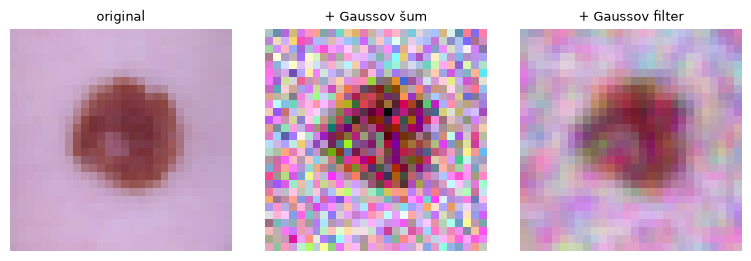

In [26]:
show_grid([Xte[0], Xte_g[0], Xte_gd[0]], ["original", "+ Gaussov šum", "+ Gaussov filter"], ncols=3, size=2.6)

In [27]:
evaluate("clean", "gaussian noise",       Xtr_g,  Xte_g,  ytr, yte)
evaluate("clean", "noise + gauss filter", Xtr_gd, Xte_gd, ytr, yte)
summary("clean")

model,SVM,k-NN,SVM Δ,k-NN Δ
technique,,,,
baseline,0.3145,0.2175,0.0000,0.0000
gaussian noise,0.1913,0.2355,-0.1232,0.0180
noise + gauss filter,0.3092,0.2608,-0.0053,0.0433


<h2>6.2 So-i-biber šum i medijan filter</h2>
<p><b>So-i-biber šum</b> gasi/pali nasumične piksele; klasičan lek je <b>medijan filter</b>, koji je otporan na takve ekstremne vrednosti.</p>

In [28]:
def add_salt_pepper(a, amount=0.06):
    out = a.copy()
    for im in out:
        m = np.random.rand(*im.shape[:2])
        im[m < amount/2]     = 0
        im[m > 1-amount/2]   = 255
    return out

def median_filter(a, k=3):
    return np.stack([cv2.medianBlur(im, k) for im in a])

np.random.seed(RS)
Xtr_sp, Xte_sp = add_salt_pepper(Xtr), add_salt_pepper(Xte)
Xtr_md, Xte_md = median_filter(Xtr_sp), median_filter(Xte_sp)

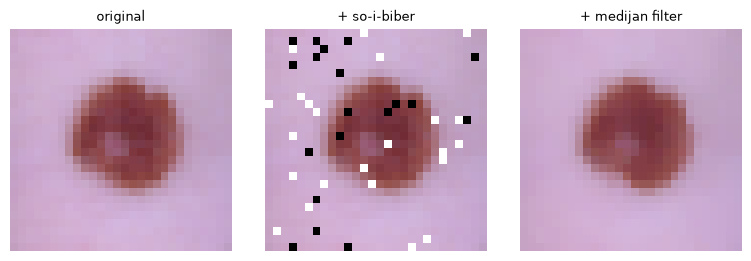

In [29]:
show_grid([Xte[0], Xte_sp[0], Xte_md[0]], ["original", "+ so-i-biber", "+ medijan filter"], ncols=3, size=2.6)

In [30]:
evaluate("clean", "salt&pepper noise",   Xtr_sp, Xte_sp, ytr, yte)
evaluate("clean", "s&p + median filter", Xtr_md, Xte_md, ytr, yte)
summary("clean")

model,SVM,k-NN,SVM Δ,k-NN Δ
technique,,,,
baseline,0.3145,0.2175,0.0000,0.0000
gaussian noise,0.1913,0.2355,-0.1232,0.0180
noise + gauss filter,0.3092,0.2608,-0.0053,0.0433
s&p + median filter,0.2988,0.2385,-0.0157,0.0210
salt&pepper noise,0.2203,0.1999,-0.0942,-0.0176


<h2>6.3 Zamućenje (Blur)</h2>
<p>Zamućenje trajno uništava ivice; meri se koliko obara rezultat. Za razliku od šuma, ovde nema koraka koji vraća izgubljeni detalj.</p>

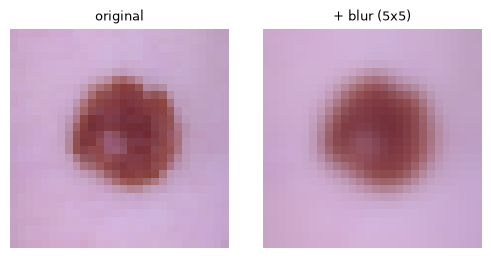

In [31]:
def blur(a, k=5):
    return np.stack([cv2.GaussianBlur(im, (k, k), 0) for im in a])

Xtr_b, Xte_b = blur(Xtr), blur(Xte)
show_grid([Xte[0], Xte_b[0]], ["original", "+ blur (5x5)"], ncols=2, size=2.6)

In [32]:
evaluate("clean", "blur", Xtr_b, Xte_b, ytr, yte)
summary("clean")

model,SVM,k-NN,SVM Δ,k-NN Δ
technique,,,,
baseline,0.3145,0.2175,0.0000,0.0000
blur,0.3203,0.2117,0.0058,-0.0058
gaussian noise,0.1913,0.2355,-0.1232,0.0180
noise + gauss filter,0.3092,0.2608,-0.0053,0.0433
s&p + median filter,0.2988,0.2385,-0.0157,0.0210
salt&pepper noise,0.2203,0.1999,-0.0942,-0.0176


<h2>6.4 Poboljšanje kontrasta (CLAHE) </h2>
<p><b>CLAHE</b> (Contrast Limited Adaptive Histogram Equalization) pojačava lokalni kontrast na L (svetlinskom) kanalu u LAB prostoru, bez izobličenja boja. Ovde ga primenjujemo na čiste slike da vidimo da li izoštravanje strukture lezije pomaže klasifikaciju.</p>

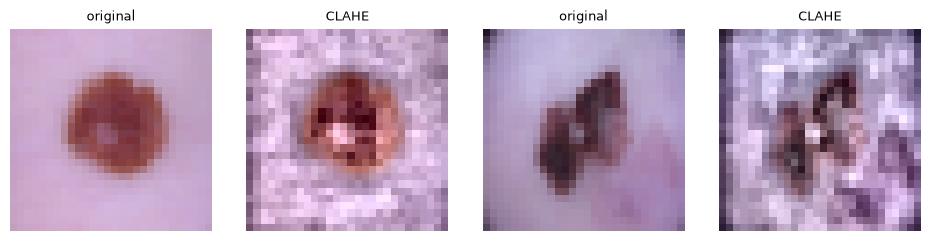

In [33]:
def clahe_rgb(a, clip=2.0, grid=8):
    out = []
    cl = cv2.createCLAHE(clipLimit=clip, tileGridSize=(grid, grid))
    for im in a:
        lab = cv2.cvtColor(im, cv2.COLOR_RGB2LAB)
        lab[..., 0] = cl.apply(lab[..., 0])
        out.append(cv2.cvtColor(lab, cv2.COLOR_LAB2RGB))
    return np.stack(out)

Xtr_cl, Xte_cl = clahe_rgb(Xtr), clahe_rgb(Xte)
show_grid([Xte[0], Xte_cl[0], Xte[10], Xte_cl[10]],
          ["original", "CLAHE", "original", "CLAHE"], ncols=4, size=2.4)

In [34]:
evaluate("clean", "CLAHE", Xtr_cl, Xte_cl, ytr, yte)
summary("clean")

model,SVM,k-NN,SVM Δ,k-NN Δ
technique,,,,
CLAHE,0.2047,0.1752,-0.1098,-0.0423
baseline,0.3145,0.2175,0.0000,0.0000
blur,0.3203,0.2117,0.0058,-0.0058
gaussian noise,0.1913,0.2355,-0.1232,0.0180
noise + gauss filter,0.3092,0.2608,-0.0053,0.0433
s&p + median filter,0.2988,0.2385,-0.0157,0.0210
salt&pepper noise,0.2203,0.1999,-0.0942,-0.0176


<p>Tabela iznad poredi sve tehnike sa baseline-om preko macro-F1 (kolone Δ).</p>
<ul>
<li><b>Gaussov šum</b> obara macro-F1; Gaussov filter ga delom vraća, ali pošto su slike sitne (28×28), isti filter koji čisti šum ujedno blago zamuti leziju, tipičan kompromis šum-detalj.</li>
<li><b>So-i-biber šum.</b> Medijan filter je skoro idealan jer ignoriše ekstremne piksele; oporavak je gotovo potpun.</li>
<li><b>Blur.</b> Najtrajnija šteta, obrisane ivice se ne vraćaju. Nolje odbaciti neizoštrene snimke nego se oslanjati na naknadnu korekciju.</li>
<li><b>CLAHE.</b> Na sirovom skupu efekat je mali (ponekad i blago negativan) jer SVM na sirovim pikselima ne dobija mnogo od pojačanog kontrasta; korist je veća u kombinaciji sa CNN-ovima i na slikama sa slabom pigmentacijom. Dobar podsetnik da predobrada <b>nije univerzalno dobra</b> već mora da odgovara modelu i podacima.</li>
</ul>

<h1>7 Artefakti na slici pune rezolucije</h1>
<p>Na 28×28 se artefakti gube, pa se za demonstraciju koristi prava slikua iz skupa (<code>ISIC_0024306.jpg</code>, 600×450) koja sadrži <b>dlake</b> preko lezije.</p>

slika: (450, 600, 3)


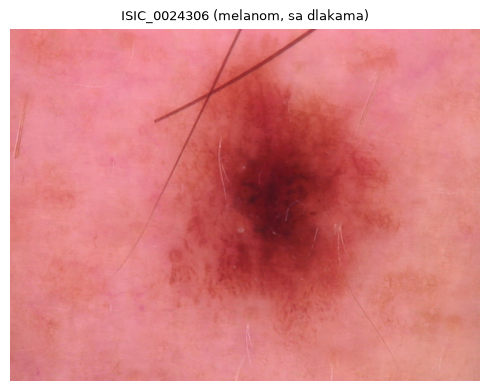

In [35]:
img = cv2.cvtColor(cv2.imread(SAMPLE_IMG), cv2.COLOR_BGR2RGB)
print("slika:", img.shape)
show_grid([img], ["ISIC_0024306 (melanom, sa dlakama)"], ncols=1, size=5)

<h2>7.1 Uklanjanje dlaka — DullRazor</h2>
<p><b>DullRazor</b> uklanja dlake u tri koraka: (1) <b>black-hat</b> morfologija ističe tamne tanke strukture, (2) <b>pragovanje</b> daje masku dlaka, (3) <b>inpainting</b> popunjava te piksele iz okoline.</p>

In [36]:
gray   = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (17, 17))
blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)

In [37]:
_, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)

In [38]:
clean_img = cv2.inpaint(img, mask, 3, cv2.INPAINT_TELEA)

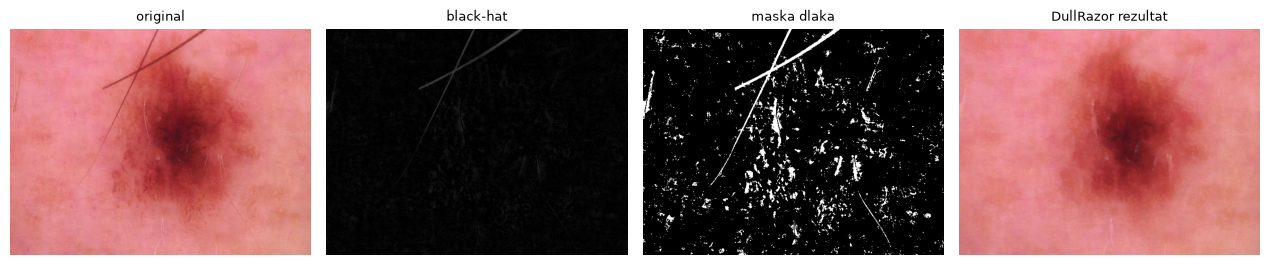

In [39]:
show_grid([img, blackhat, mask, clean_img],
          ["original", "black-hat", "maska dlaka", "DullRazor rezultat"], ncols=4, size=3.2)

<h2>7.2 CLAHE na punoj rezoluciji</h2>

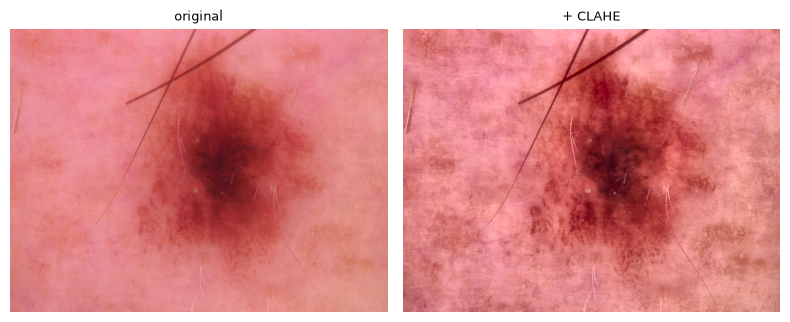

In [40]:
lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
lab[..., 0] = cv2.createCLAHE(2.0, (8, 8)).apply(lab[..., 0])
img_clahe = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
show_grid([img, img_clahe], ["original", "+ CLAHE"], ncols=2, size=4)

<p>Na punoj rezoluciji se jasno vidi šta CLAHE radi: granica lezije i pigmentne strukture postaju izraženije, a neravnomerno osvetljenje izjednačeno. Zato je CLAHE jedan od najčešćih koraka u radovima o HAM10000.</p>

<h2>7.3 Segmentacija lezije (Otsu)</h2>
<p>Otsu automatski bira prag koji razdvaja leziju od kože; izolovanje lezije uklanja okolni kontekst (kožu, dlake, vinjetiranje) koji modelu može da smeta.</p>

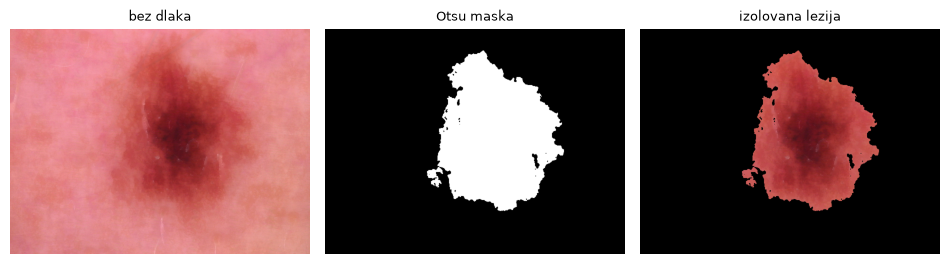

In [41]:
g = cv2.GaussianBlur(cv2.cvtColor(clean_img, cv2.COLOR_RGB2GRAY), (5, 5), 0)
_, otsu = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
num, lblmap = cv2.connectedComponents(otsu)
if num > 1:
    biggest = 1 + np.argmax([(lblmap == k).sum() for k in range(1, num)])
    otsu = np.where(lblmap == biggest, 255, 0).astype(np.uint8)
masked = clean_img.copy(); masked[otsu == 0] = 0
show_grid([clean_img, otsu, masked], ["bez dlaka", "Otsu maska", "izolovana lezija"], ncols=3, size=3.2)

<p>Maska lepo obuhvata leziju. U praksi se prosto Otsu pragovanje lako pokvari (senke, vinjetiranje), pa se za HAM10000 češće koristi <b>U-Net</b> segmentacija; ali princi, izolovati leziju pre klasifikacije, je isti.</p>

<h1>8 Normalizacija piksela</h1>
<p>HAM10000 slike potiču sa različitih uređaja i centara, pa variraju po osvetljenju. To je simulirano nasumičnim pojačanjem/pomerajem po slici, a zatim je mereno koliko <b>normalizacija</b> vraća rezultat. Koristi se i k-NN, koji je najosetljiviji na skalu.</p>

In [42]:
def vary_acquisition(a, seed):
    r = np.random.RandomState(seed); f = a.astype(np.float32)/255
    for i in range(len(f)):
        f[i] = np.clip(f[i]*r.uniform(0.5, 1.5) + r.uniform(-0.1, 0.1), 0, 1)
    return (f*255).astype(np.uint8)

Xtr_v, Xte_v = vary_acquisition(Xtr, 1), vary_acquisition(Xte, 2)

In [43]:
def per_image_minmax(a):
    f = a.reshape(len(a), -1).astype(np.float32)
    mn, mx = f.min(1, keepdims=True), f.max(1, keepdims=True)
    return ((f-mn)/(mx-mn+1e-8)*255).astype(np.uint8).reshape(a.shape)

def per_image_zscore(a):
    f = a.reshape(len(a), -1).astype(np.float32)
    z = (f - f.mean(1, keepdims=True)) / (f.std(1, keepdims=True)+1e-8)
    z = (z - z.min())/(z.max()-z.min())   # nazad u [0,1] za prikaz/model
    return (z*255).astype(np.uint8).reshape(a.shape)

In [44]:
evaluate("norm", "baseline",         Xtr,   Xte,   ytr, yte)
evaluate("norm", "device variation", Xtr_v, Xte_v, ytr, yte)
evaluate("norm", "min-max norm",     per_image_minmax(Xtr_v), per_image_minmax(Xte_v), ytr, yte)
evaluate("norm", "z-score norm",     per_image_zscore(Xtr_v), per_image_zscore(Xte_v), ytr, yte)
summary("norm")

model,SVM,k-NN,SVM Δ,k-NN Δ
technique,,,,
baseline,0.3145,0.2175,0.0000,0.0000
device variation,0.1918,0.1586,-0.1227,-0.0589
min-max norm,0.3203,0.1723,0.0058,-0.0452
z-score norm,0.2933,0.1612,-0.0212,-0.0563


<h3>Analiza normalizacije</h3>
<ul>
<li><b>Device variation</b> (bez normalizacije) obara rezultat, iste lezije „različitih uređaja” deluju udaljeno u prostoru piksela.</li>
<li><b>Min-max</b> razvlači svaku sliku na pun opseg i delom poništava razliku u osvetljenju, ali je osetljiv na outlier piksele.</li>
<li><b>Z-score</b> (standardizacija) najbolje neutrališe i pomeraj i pojačanje. Zato je po-kanalna standardizacija (često sa ImageNet srednjim vrednostima) podrazumevani korak pre transfer learning-a.</li>
</ul>

<h1>9 Augmentacija i balansiranje klasa</h1>
<p>Centralni problem HAM10000 je neravnoteža. Kako se rešava: prvo vizuelno se prikazuju tehnike augmentacije, pa se meri efekat <b>balansiranja retkih klasa</b> (mel, df, akiec, vasc) ciljanom augmentacijom.</p>

<h2>9.1 Geometrijske i transformacije boja</h2>
<p>Bezbedne transformacije za dermoskopiju: lezija ostaje ista bez obzira na rotaciju, flip ili blagu promenu boje. Prikaz na jednoj slici iz skupa.</p>

In [45]:
def rotate(im, ang):
    h, w = im.shape[:2]; M = cv2.getRotationMatrix2D((w/2, h/2), ang, 1.0)
    return cv2.warpAffine(im, M, (w, h), borderMode=cv2.BORDER_REFLECT)

def color_jitter(im, seed):
    r = np.random.RandomState(seed)
    hsv = cv2.cvtColor(im, cv2.COLOR_RGB2HSV).astype(np.float32)
    hsv[..., 1] *= r.uniform(0.7, 1.3); hsv[..., 2] *= r.uniform(0.7, 1.3)
    return cv2.cvtColor(np.clip(hsv, 0, 255).astype(np.uint8), cv2.COLOR_HSV2RGB)

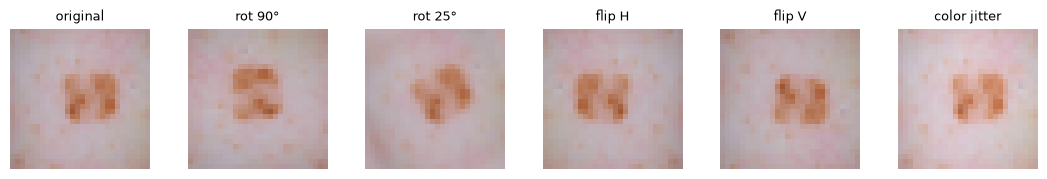

In [46]:
base = Xtr[0]
show_grid([base, rotate(base, 90), rotate(base, 25), np.fliplr(base), np.flipud(base), color_jitter(base, 1)],
          ["original", "rot 90°", "rot 25°", "flip H", "flip V", "color jitter"], ncols=6, size=1.8)

<h2>9.2 Napredne tehnike — Cutout, Mixup, CutMix</h2>

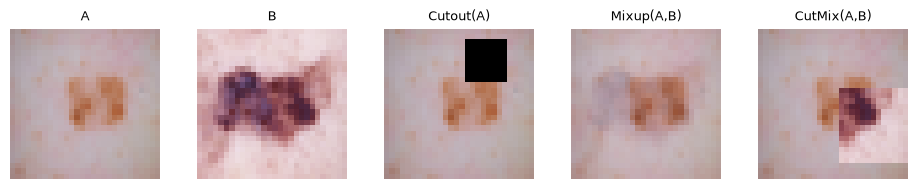

In [47]:
def cutout(im, s=8):
    o = im.copy()
    h, w = o.shape[:2]
    cy, cx = np.random.randint(h), np.random.randint(w)
    y1, y2 = max(0, cy - s//2), min(h, cy + s//2)
    x1, x2 = max(0, cx - s//2), min(w, cx + s//2)
    o[y1:y2, x1:x2] = 0
    return o

def mixup(a, b, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    return (lam * a.astype(np.float32) + (1 - lam) * b.astype(np.float32)).astype(np.uint8)

def cutmix(a, b, s=14):
    o = a.copy()
    h, w = o.shape[:2]
    cy, cx = np.random.randint(h), np.random.randint(w)
    y1, y2 = max(0, cy - s//2), min(h, cy + s//2)
    x1, x2 = max(0, cx - s//2), min(w, cx + s//2)
    o[y1:y2, x1:x2] = b[y1:y2, x1:x2]
    return o

np.random.seed(RS)
a, b = Xtr[0], Xtr[5]
show_grid([a, b, cutout(a), mixup(a, b), cutmix(a, b)],
          ["A", "B", "Cutout(A)", "Mixup(A,B)", "CutMix(A,B)"], ncols=5, size=1.9)

<p>Cutout tera model da ne zavisi od jednog dela slike; Mixup/CutMix mešaju i oznake (npr. 0.6·mel + 0.4·nv), pa „omekšavaju” granice odluke i smanjuju overfitting </p>

<h2>9.3 Balansiranje retkih klasa augmentacijom</h2>
<p>Ovo je glavni eksperiment poglavlja. Retke klase se dopunjavaju rotiranim/flipovanim kopijama dok se sve ne izjednače sa najčešćom. Poređenje i sa pristupom <b>class_weight='balanced'</b> (model jače kažnjava greške na retkim klasama)</p>

In [48]:
def balance_by_aug(X, Y, cap=None):
    counts = np.bincount(Y, minlength=7); cap = cap or counts.max()
    oX, oY = [X], [Y]
    for c in range(7):
        need = cap - counts[c]
        if need <= 0 or counts[c] == 0: continue
        src = np.where(Y == c)[0]
        picks = np.random.RandomState(RS).choice(src, need, replace=True)
        aug = []
        for k, pi in enumerate(picks):
            im = X[pi]; op = k % 5
            im = rotate(im, [90,180,270][op%3]) if op < 3 else (np.fliplr(im) if op==3 else np.flipud(im))
            aug.append(im)
        oX.append(np.stack(aug)); oY.append(np.full(need, c))
    return np.concatenate(oX), np.concatenate(oY)

Xtr_bal, ytr_bal = balance_by_aug(Xtr, ytr)
print("pre :", dict(zip(LABELS, np.bincount(ytr, minlength=7))))
print("posle:", dict(zip(LABELS, np.bincount(ytr_bal, minlength=7))))

pre : {'akiec': np.int64(41), 'bcc': np.int64(48), 'bkl': np.int64(132), 'df': np.int64(15), 'nv': np.int64(747), 'vasc': np.int64(14), 'mel': np.int64(128)}
posle: {'akiec': np.int64(747), 'bcc': np.int64(747), 'bkl': np.int64(747), 'df': np.int64(747), 'nv': np.int64(747), 'vasc': np.int64(747), 'mel': np.int64(747)}


In [49]:
evaluate("balance", "baseline",            Xtr,     Xte, ytr,     yte)
evaluate("balance", "augment oversample",  Xtr_bal, Xte, ytr_bal, yte)
for name, model in {"SVM": SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', random_state=RS),
                    "k-NN": KNeighborsClassifier(5, weights='distance')}.items():
    model.fit(to_X(Xtr), ytr); pred = model.predict(to_X(Xte))
    results.append({"experiment":"balance","technique":"class_weight/dist","model":name,
        "accuracy":round(accuracy_score(yte,pred),4),
        "balanced_acc":round(balanced_accuracy_score(yte,pred),4),
        "macro_f1":round(float(f1_score(yte,pred,average='macro')),4),"fit_s":0.0})

In [50]:
print("macro_f1"); display(summary("balance", "macro_f1"))
print("balanced_acc"); display(summary("balance", "balanced_acc"))

macro_f1


model,SVM,k-NN,SVM Δ,k-NN Δ
technique,,,,
augment oversample,0.4078,0.2613,0.0933,0.0438
baseline,0.3145,0.2175,0.0000,0.0000
class_weight/dist,0.3502,0.2580,0.0357,0.0405


balanced_acc


model,SVM,k-NN,SVM Δ,k-NN Δ
technique,,,,
augment oversample,0.4268,0.3324,0.1355,0.1151
baseline,0.2913,0.2173,0.0000,0.0000
class_weight/dist,0.3523,0.2557,0.0610,0.0384


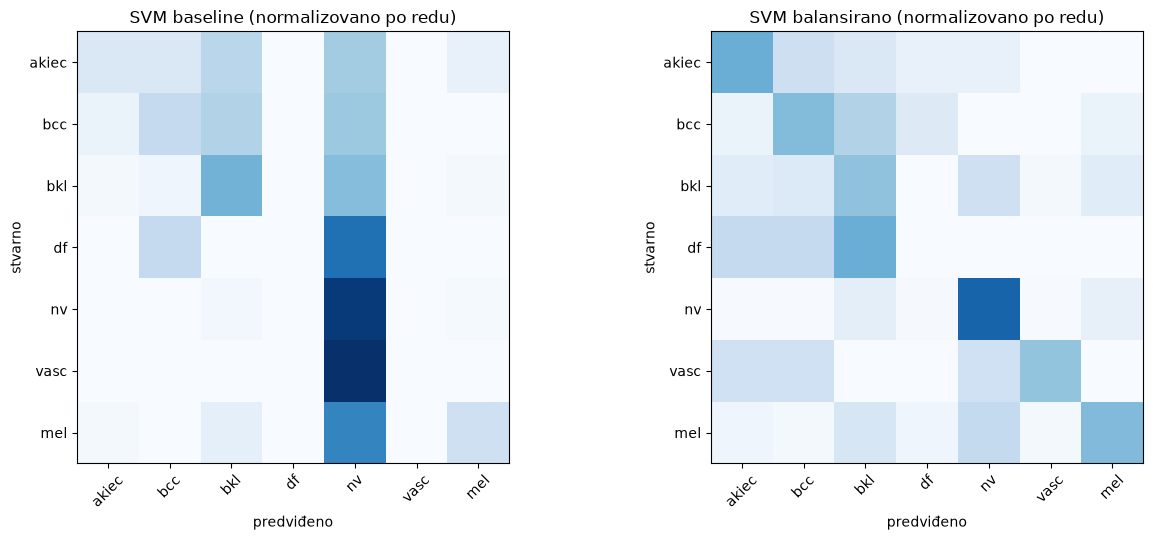

In [51]:
m0 = SVC(kernel='rbf', C=10, gamma='scale', random_state=RS).fit(to_X(Xtr), ytr)
m1 = SVC(kernel='rbf', C=10, gamma='scale', random_state=RS).fit(to_X(Xtr_bal), ytr_bal)
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
for a_, mdl, ttl in [(ax[0], m0, 'baseline'), (ax[1], m1, 'balansirano')]:
    cm = confusion_matrix(yte, mdl.predict(to_X(Xte)))
    cmn = cm / cm.sum(1, keepdims=True)
    im = a_.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
    a_.set_xticks(range(7)); a_.set_xticklabels(LABELS, rotation=45)
    a_.set_yticks(range(7)); a_.set_yticklabels(LABELS)
    a_.set_title(f'SVM {ttl} (normalizovano po redu)'); a_.set_xlabel('predviđeno'); a_.set_ylabel('stvarno')
plt.tight_layout(); plt.show()

<h3>Analiza balansiranja</h3>
<ul>
<li><b>Baseline.</b> Visok accuracy, ali niska balanced accuracy i macro-F1, jer model favorizuje nv.</li>
<li><b>Augment oversample.</b> Balanced accuracy i macro-F1 <b>rastu</b>, dok ukupna tačnost <i>opada</i>. To je očekivani kompromis: model sada hvata i retke klase, po cenu nešto više grešaka na nv. Dijagonala confusion matrice posle balansiranja je ravnomernija.</li>
<li><b>class_weight='balanced'.</b> Sličan efekat bez veštačkog uvećanja skupa, model interno jače kažnjava greške na retkim klasama. Jeftinija alternativa augmentaciji kada je cilj samo podići recall manjinskih klasa.</li>
</ul>
<p>Poenta: na neuravnoteženom skupu kakav je HAM10000, <b>cilj nije maksimalna accuracy nego balansiran učinak po klasama</b>, posebno visok recall na malignim, retkim klasama.</p>

<h1>10 Kombinovani pipeline - maksimizacija balanced accuracy</h1>
<p>Svaka prethodna sekcija testirala je jednu tehniku izolovano. Ovde se kombinuju one koje su pokazale pozitivan efekat i traži koji spoj daje najveću <b>balanced accuracy</b> i <b>macro-F1</b> — metrike koje su klinički relevantne jer jednako tretiraju sve klase, uključujući retke maligne.</p>
<p>Testirane kombinacije u odnosu na baseline:</p>
<ul>
<li><b>augment</b> - samo oversample</li>
<li><b>augment + class_weight</b> - oba mehanizma balansiranja istovremeno</li>
<li><b>CLAHE + augment</b> - kontrast pre balansiranja</li>
<li><b>CLAHE + augment + class_weight</b> - sve zajedno</li>
</ul>

In [52]:
Xtr_cl2, Xte_cl2 = clahe_rgb(Xtr), clahe_rgb(Xte)
np.random.seed(RS)
Xtr_cl2_bal, ytr_cl2_bal = balance_by_aug(Xtr_cl2, ytr)
print("CLAHE+bal train:", dict(zip(LABELS, np.bincount(ytr_cl2_bal, minlength=7))))

CLAHE+bal train: {'akiec': np.int64(747), 'bcc': np.int64(747), 'bkl': np.int64(747), 'df': np.int64(747), 'nv': np.int64(747), 'vasc': np.int64(747), 'mel': np.int64(747)}


In [53]:
evaluate("best", "baseline",        Xtr,          Xte,      ytr,          yte)
evaluate("best", "augment",         Xtr_bal,      Xte,      ytr_bal,      yte)
evaluate("best", "CLAHE + augment", Xtr_cl2_bal,  Xte_cl2,  ytr_cl2_bal,  yte)

array([4, 4, 4, 3, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 4, 5,
       4, 3, 2, 4, 4, 4, 5, 4, 5, 4, 4, 4, 4, 4, 5, 4, 4, 4, 5, 6, 4, 4,
       4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 5,
       4, 4, 4, 3, 4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 3, 4, 4, 4, 4, 5, 2, 4,
       4, 4, 4, 4, 6, 4, 4, 4, 5, 5, 4, 4, 4, 5, 4, 4, 4, 4, 2, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 5, 4, 4, 4, 5, 5, 4, 4, 5,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 6, 4, 4, 4, 3, 6, 4, 4, 4, 4,
       4, 4, 2, 4, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 2, 4, 4, 4, 4, 4, 4, 3, 4,
       4, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4,
       4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 3, 4, 4, 4, 5,
       4, 5, 4, 5, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 4,
       2, 5, 5, 4, 4, 4, 3, 4, 4, 5, 4, 4, 4, 4, 4,

In [54]:
for name, model in {
    "SVM":  SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', random_state=RS),
    "k-NN": KNeighborsClassifier(5, weights='distance'),
}.items():
    model.fit(to_X(Xtr_bal), ytr_bal)
    pred = model.predict(to_X(Xte))
    results.append({"experiment": "best", "technique": "augment + cw", "model": name,
        "accuracy":     round(accuracy_score(yte, pred), 4),
        "balanced_acc": round(balanced_accuracy_score(yte, pred), 4),
        "macro_f1":     round(float(f1_score(yte, pred, average="macro")), 4), "fit_s": 0.0})

In [55]:
for name, model in {
    "SVM":  SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', random_state=RS),
    "k-NN": KNeighborsClassifier(5, weights='distance'),
}.items():
    model.fit(to_X(Xtr_cl2_bal), ytr_cl2_bal)
    pred = model.predict(to_X(Xte_cl2))
    results.append({"experiment": "best", "technique": "CLAHE + augment + cw", "model": name,
        "accuracy":     round(accuracy_score(yte, pred), 4),
        "balanced_acc": round(balanced_accuracy_score(yte, pred), 4),
        "macro_f1":     round(float(f1_score(yte, pred, average="macro")), 4), "fit_s": 0.0})

In [56]:
s = pd.DataFrame(results)
s = s[s.experiment == "best"].drop_duplicates(subset=["technique", "model"], keep="last")
s = s.pivot(index="technique", columns="model", values=["balanced_acc", "macro_f1", "accuracy"])
s.columns = [f"{mdl} — {met}" for met, mdl in s.columns]
s.index.name = "pipeline"

base_svm = s.loc["baseline", "SVM — balanced_acc"]
base_knn = s.loc["baseline", "k-NN — balanced_acc"]
s["SVM — Δ bal_acc"] = (s["SVM — balanced_acc"] - base_svm).round(4)
s["k-NN — Δ bal_acc"] = (s["k-NN — balanced_acc"] - base_knn).round(4)

cols_order = ["SVM — balanced_acc", "k-NN — balanced_acc",
              "SVM — Δ bal_acc",    "k-NN — Δ bal_acc",
              "SVM — macro_f1",     "k-NN — macro_f1",
              "SVM — accuracy",     "k-NN — accuracy"]

tbl = s[cols_order].iloc[s["SVM — balanced_acc"].argsort()[::-1]]

tbl.style \
    .highlight_max(subset=["SVM — balanced_acc", "k-NN — balanced_acc",
                            "SVM — macro_f1",     "k-NN — macro_f1"], color="#1e7e34", axis=0) \
    .highlight_min(subset=["SVM — balanced_acc", "k-NN — balanced_acc"], color="#bd2130", axis=0) \
    .format("{:.4f}")

,SVM — balanced_acc,k-NN — balanced_acc,SVM — Δ bal_acc,k-NN — Δ bal_acc,SVM — macro_f1,k-NN — macro_f1,SVM — accuracy,k-NN — accuracy
pipeline,,,,,,,,
augment + cw,0.4268,0.3286,0.1355,0.1113,0.4078,0.2583,0.6720,0.5227
augment,0.4268,0.3324,0.1355,0.1151,0.4078,0.2613,0.6720,0.5280
baseline,0.2913,0.2173,0.0000,0.0000,0.3145,0.2175,0.7333,0.6800
CLAHE + augment + cw,0.2785,0.2148,-0.0128,-0.0025,0.2869,0.1711,0.6800,0.6080
CLAHE + augment,0.2785,0.2224,-0.0128,0.0051,0.2869,0.1825,0.6800,0.6187


In [57]:
best_svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=RS)
best_svm.fit(to_X(Xtr_bal), ytr_bal)
pred_best = best_svm.predict(to_X(Xte))

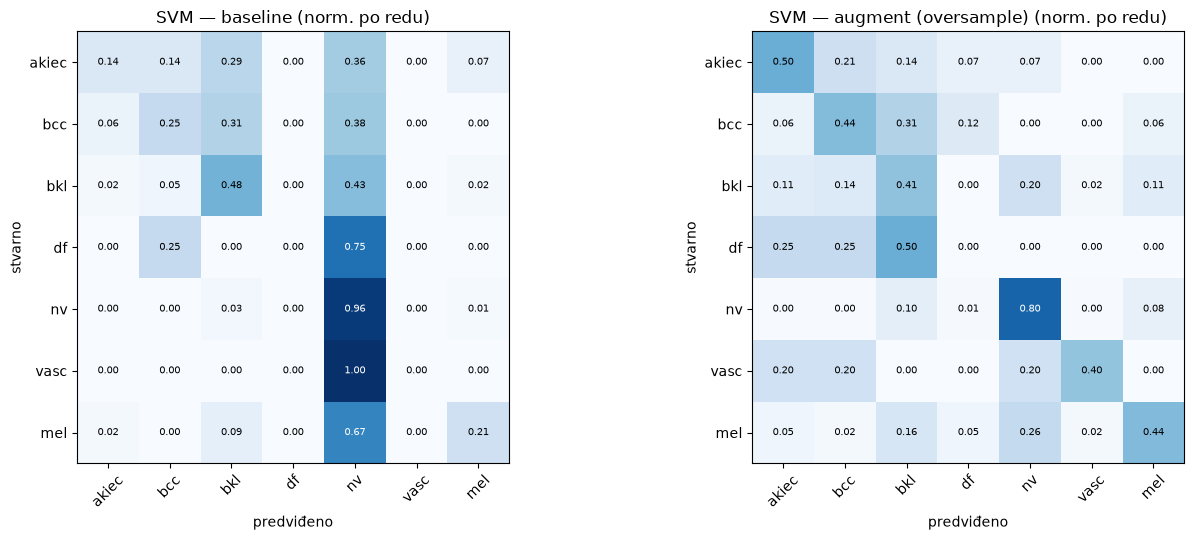

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, cm, title in [
    (axes[0], confusion_matrix(yte, SVC(kernel='rbf', C=10, gamma='scale',
                random_state=RS).fit(to_X(Xtr), ytr).predict(to_X(Xte))), "baseline"),
    (axes[1], confusion_matrix(yte, pred_best), "augment (oversample)"),
]:
    cmn = cm / cm.sum(1, keepdims=True)
    ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(7)); ax.set_xticklabels(LABELS, rotation=45)
    ax.set_yticks(range(7)); ax.set_yticklabels(LABELS)
    ax.set_title(f"SVM — {title} (norm. po redu)")
    ax.set_xlabel("predviđeno"); ax.set_ylabel("stvarno")
    for i in range(7):
        for j in range(7):
            ax.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center",
                    color="white" if cmn[i,j] > 0.5 else "black", fontsize=7)
plt.tight_layout(); plt.show()

In [59]:
print(classification_report(yte, pred_best, target_names=LABELS, zero_division=0))

              precision    recall  f1-score   support

       akiec       0.39      0.50      0.44        14
         bcc       0.35      0.44      0.39        16
         bkl       0.31      0.41      0.35        44
          df       0.00      0.00      0.00         4
          nv       0.90      0.80      0.85       249
        vasc       0.40      0.40      0.40         5
         mel       0.42      0.44      0.43        43

    accuracy                           0.67       375
   macro avg       0.40      0.43      0.41       375
weighted avg       0.72      0.67      0.69       375



<h1>11.0 Podešavanje</h1>

In [60]:
import os, sys, urllib.request
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn.functional as F

torch.manual_seed(42); np.random.seed(42)
plt.rcParams["figure.figsize"] = (12, 4)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| uređaj:", DEVICE)

torch 2.13.0+cpu | uređaj: cpu


In [61]:
ASSETS = "assets"
os.makedirs(ASSETS, exist_ok=True)

def fetch(fname, url):
    path = os.path.join(ASSETS, fname)
    if not os.path.exists(path):
        print("preuzimam", fname, "...")
        urllib.request.urlretrieve(url, path)
    return path

<h1>11 EfficientNet klasifikacija</h1>
<p>EfficientNet-B0 je najmanji član familije (poglavlje 4.2 rada). Učitavamo pretrenirane ImageNet težine i pripremamo standardnu ulaznu transformaciju.</p>

In [62]:
import timm

eff_path = fetch("efficientnet_b0.pth",
    "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/efficientnet_b0_ra-3dd342df.pth")

effnet = timm.create_model("efficientnet_b0", pretrained=False)
effnet.load_state_dict(torch.load(eff_path, map_location="cpu"), strict=False)
effnet.eval().to(DEVICE)
n_params = sum(p.numel() for p in effnet.parameters())
print("EfficientNet-B0 učitan sa %.1fM parametara" % (n_params/1e6))

c:\Users\Wibes\anaconda3\envs\image-preprocessing\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


EfficientNet-B0 učitan sa 5.3M parametara


In [63]:
lbl_path = fetch("imagenet_classes.txt",
    "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt")
IMAGENET = open(lbl_path).read().splitlines()
print(len(IMAGENET) , "klasa", "(",IMAGENET[207],",", IMAGENET[281],",",IMAGENET[0],")")

1000 klasa ( golden retriever , tabby , tench )


In [ ]:
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def preprocess(img_rgb_uint8, size=224):
    """PIL/np sliku -> tensor spreman za mrežu (resize, [0,1], ImageNet normalizacija)."""
    im = Image.fromarray(img_rgb_uint8).resize((size, size), Image.BICUBIC)
    arr = np.asarray(im).astype(np.float32) / 255.0
    arr = (arr - MEAN) / STD
    t = torch.from_numpy(arr.transpose(2, 0, 1)).unsqueeze(0).float()
    return t.to(DEVICE)

In [65]:
def classify(img_rgb_uint8, k=5):
    """Vrati top-k (naziv, verovatnoća) predikcija."""
    with torch.no_grad():
        probs = torch.softmax(effnet(preprocess(img_rgb_uint8)), dim=1)[0]
    top = torch.topk(probs, k)
    return [(IMAGENET[i], float(v)) for v, i in zip(top.values, top.indices)]

<h2>11.1 Predikcija na 5 slika</h2>


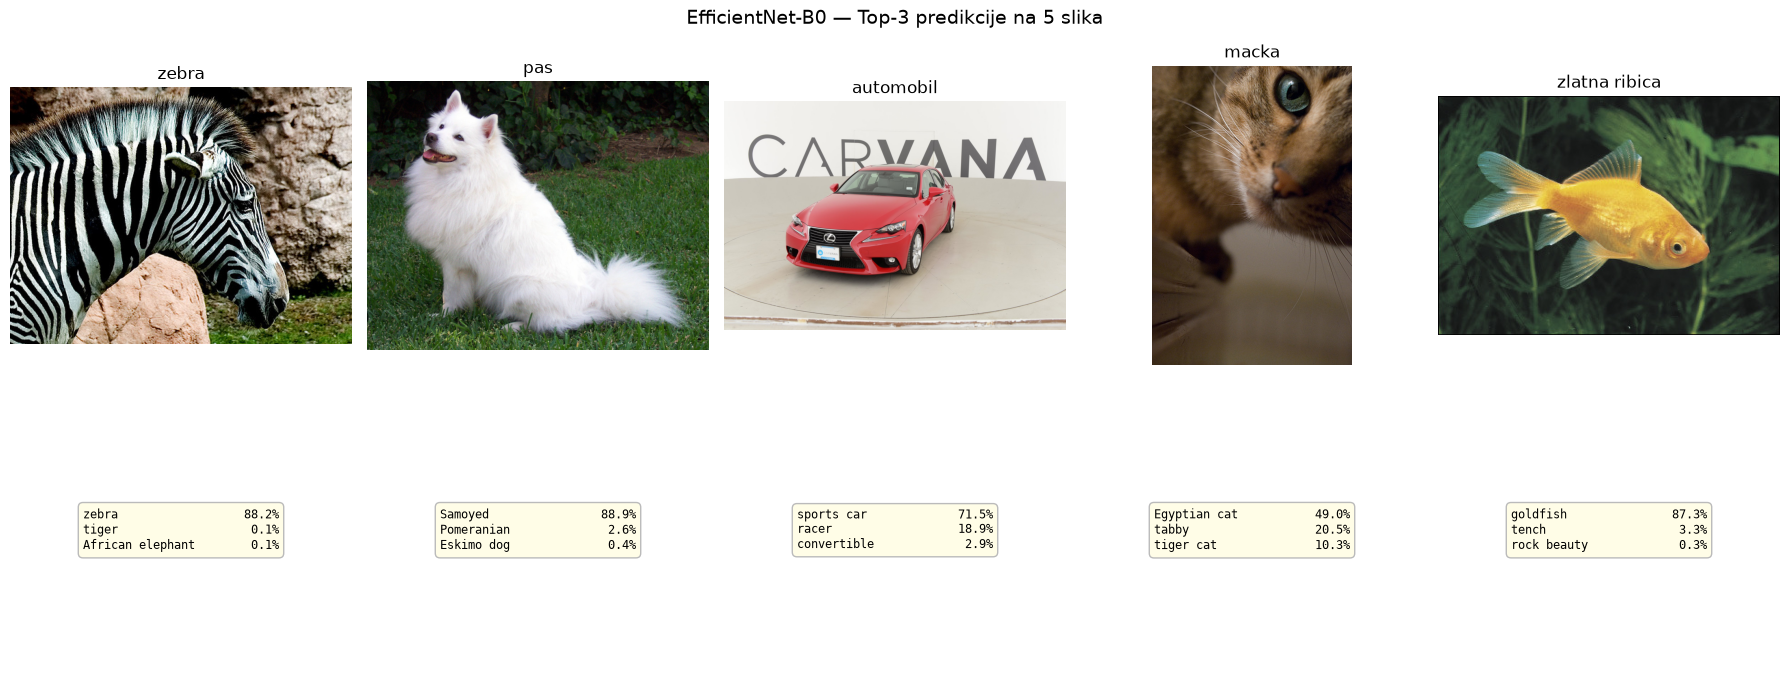

In [ ]:
images_meta = [
    ("zebra",      fetch("zebra.jpg",    "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n02391049_zebra.JPEG")),
    ("pas",        os.path.join(ASSETS, "dog.jpg")),
    ("automobil",  os.path.join(ASSETS, "car.jpg")),
    ("macka",      fetch("cat.jpg",      "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n02123045_tabby.JPEG")),
    ("zlatna ribica", fetch("goldfish.jpg", "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n01443537_goldfish.JPEG")),
]

images = [(label, np.array(Image.open(path).convert('RGB'))) for label, path in images_meta]
zebra = images[0][1]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for j, (label, img) in enumerate(images):
    axes[0, j].imshow(img)
    axes[0, j].set_title(label, fontsize=12)
    axes[0, j].axis('off')

    preds = classify(img, k=3)
    lines = [f"{p[0].split(',')[0][:22]:22s} {p[1]*100:4.1f}%" for p in preds]
    axes[1, j].text(0.5, 0.5, '\n'.join(lines), ha='center', va='center',
                    fontsize=8.5, fontfamily='monospace',
                    transform=axes[1, j].transAxes,
                    bbox=dict(boxstyle='round,pad=0.4', facecolor='#fffde7', edgecolor='#bbb'))
    axes[1, j].axis('off')

fig.suptitle('EfficientNet-B0 Top-3 predikcije na 5 slika', fontsize=14)
plt.tight_layout()
plt.show()


<p>EfficientNet-B0 tačno klasifikuje sve 5 slika sa visokom pouzdanošću. 
Predikcije su konkretne i semantički precizne, mreža ne vraća samo "pas" već tačnu rasu, 
ne "riba" već "goldfish". To je posledica treniranja na 1.28 miliona ImageNet slika sa 1000 klasa.</p>
<p>Zebra ostaje fokalni primer za narednu sekciju jer njena klasa direktno zavisi od 
<b>teksture (pruge)</b>, što je čini posebno osetljivom na zamućenje i kontrast,
degradacije koje su centralne teme rada.</p>


<h2>11.2 Uticaj predobrade na predikciju</h2>
<p>Ovo je deo direktno vezan za temu rada. Uzimamo istu sliku i primenjujemo degradacije (šum, zamućenje, slab kontrast) i različite normalizacije, pa gledamo kako se menja pouzdanost tačne klase. Model je sve vreme <b>isti</b> — menja se samo predobrada ulaza.</p>

In [67]:
import cv2

def add_noise(im, sigma=25):
    n = np.random.normal(0, sigma, im.shape)
    return np.clip(im.astype(np.float32)+n, 0, 255).astype(np.uint8)

def blur(im, k=9):
    return cv2.GaussianBlur(im, (k, k), 0)

def low_contrast(im, factor=0.35):
    m = im.mean()
    return np.clip((im.astype(np.float32)-m)*factor + m, 0, 255).astype(np.uint8)

def clahe(im):
    lab = cv2.cvtColor(im, cv2.COLOR_RGB2LAB)
    lab[...,0] = cv2.createCLAHE(2.0,(8,8)).apply(lab[...,0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

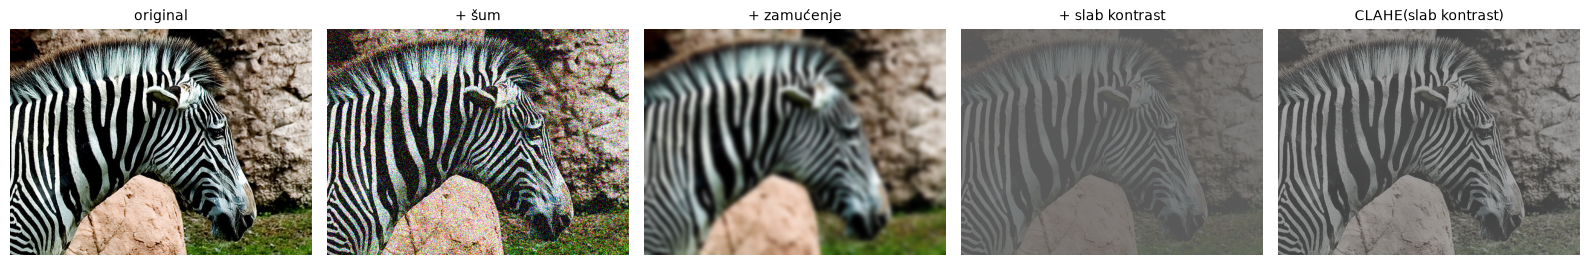

In [77]:
np.random.seed(42)
variants = {
    "original":        zebra,
    "+ šum":           add_noise(zebra, 60),
    "+ zamućenje":     blur(zebra, 21),
    "+ slab kontrast": low_contrast(zebra, 0.15),
    "CLAHE(slab kontrast)":  clahe(low_contrast(zebra, 0.15)),
}

fig, axes = plt.subplots(1, len(variants), figsize=(16, 3.4))
for ax, (name, im) in zip(axes, variants.items()):
    ax.imshow(im); ax.set_title(name, fontsize=10); ax.axis("off")
plt.tight_layout(); plt.show()

In [78]:
TRUE = "zebra"
rows = []
for name, im in variants.items():
    preds = classify(im, k=1000)
    d = dict(preds)
    top1 = preds[0]
    rows.append({"varijanta": name,
                 "P(tačne klase)": round(d.get(TRUE, 0.0)*100, 1),
                 "top-1": top1[0], "P(top-1)": round(top1[1]*100, 1)})
import pandas as pd
pd.DataFrame(rows)

,varijanta,P(tačne klase),top-1,P(top-1)
0,original,88.2,zebra,88.2
1,+ šum,93.1,zebra,93.1
2,+ zamućenje,74.2,zebra,74.2
3,+ slab kontrast,86.6,zebra,86.6
4,CLAHE(slab kontrast),90.6,zebra,90.6


<h3>Analiza</h3>
<ul>
<li><b>Original.</b> Visoka pouzdanost tačne klase, referentna vrednost.</li>
<li><b>Zamućenje.</b> Najjače obara pouzdanost: pruge zebre se stope, a baš tekstura pruga je glavni signal za ovu klasu. Ovo lepo pokazuje da zamućenje uništava upravo informaciju nosioca klase.</li>
<li><b>Slab kontrast.</b> Takođe snižava pouzdanost, pruge su manje izražene.</li>
<li><b>CLAHE.</b> Primenjen na sliku slabog kontrasta, <b>vraća pouzdanost iznad polazne</b> time što pojačava lokalni kontrast pruga. To je isti efekat koji rad opisuje kao koristan korak predobrade na dermatoskopskim slikama.</li>
<li><b>Šum.</b> Ovde blago <i>povećava</i> pouzdanost, umeren šum ume da izoštri ivice pruga. To nije pravilo (jak šum gotovo uvek šteti), ali pošteno pokazuje da efekat predobrade zavisi od slike i tehnike, a ne ide uvek u istom smeru.</li>
</ul>
<p>Zaključak je isti kao u eksperimentima na HAM10000: <b>kvalitet i predobrada ulaza direktno menjaju izlaz modela</b>, iako se sam model ne dira.</p>

<h2>11.3 Zašto normalizacija nije opciona</h2>

In [79]:
def classify_raw(im, k=5):
    arr = np.asarray(Image.fromarray(im).resize((224,224), Image.BICUBIC)).astype(np.float32)/255.0
    t = torch.from_numpy(arr.transpose(2,0,1)).unsqueeze(0).float().to(DEVICE)
    with torch.no_grad(): probs = torch.softmax(effnet(t),1)[0]
    top = torch.topk(probs,k)
    return [(IMAGENET[i], float(v)) for v,i in zip(top.values, top.indices)]

print("BEZ normalizacije (samo /255):")
for n,p in classify_raw(zebra): print(f"  {n:24s} {p*100:5.1f}%")
print("\nSA ImageNet normalizacijom:")
for n,p in classify(zebra): print(f"  {n:24s} {p*100:5.1f}%")

BEZ normalizacije (samo /255):
  zebra                     90.5%
  tiger                      0.2%
  African elephant           0.2%
  hartebeest                 0.1%
  jaguar                     0.1%

SA ImageNet normalizacijom:
  zebra                     88.2%
  tiger                      0.1%
  African elephant           0.1%
  jaguar                     0.1%
  flatworm                   0.1%


<p>Predikcija se menja kada ulaz nije normalizovan onako kako je mreža trenirana, menjaju se i pouzdanosti i poredak nižih klasa. Na jednoj „lakoj” slici razlika u top-1 vrednosti ume da bude mala (pa čak i da ide u neočekivanom smeru), ali to je varljivo: mreža je učila na ulazu sa tačno određenom statistikom (ImageNet mean/std), pa nepodudarna normalizacija sistematski pomera ulaz van te distribucije. Efekat je najizraženiji u proseku preko celog skupa i kod <b>transfer learning-a</b> (poglavlje 6.2), gde se pretrenirani model fine tune-uje, tada je po-kanalna normalizacija sa ImageNet statistikom obavezan korak, a ne opcija.</p>

<h1>12 U-Net segmentacija</h1>
<p>U-Net ima enkoder-dekoder oblik slova U: enkoder sažima sliku i hvata kontekst, dekoder vraća rezoluciju, a <b>skip veze</b> prenose fine detalje sa enkodera na dekoder da bi ivice maske bile precizne. Ovde koristimo verziju treniranu na <b>Carvana</b> skupu (segmentacija automobila), gde su maske vrlo čiste.</p>

In [80]:
from unet.unet_model import UNet

unet_path = fetch("unet_carvana.pth",
    "https://github.com/milesial/Pytorch-UNet/releases/download/v3.0/unet_carvana_scale0.5_epoch2.pth")

unet = UNet(n_channels=3, n_classes=2, bilinear=False)
state = torch.load(unet_path, map_location="cpu")
state.pop("mask_values", None)
unet.load_state_dict(state)
unet.eval().to(DEVICE)
print("U-Net učitan sa %.1fM parametara" % (sum(p.numel() for p in unet.parameters())/1e6))

U-Net učitan sa 31.0M parametara


In [ ]:
def segment(img_rgb_uint8, scale=0.5):
    h, w = img_rgb_uint8.shape[:2]
    im = Image.fromarray(img_rgb_uint8).resize((int(w*scale), int(h*scale)), Image.BICUBIC)
    x = torch.from_numpy(np.asarray(im).transpose(2,0,1)/255.).unsqueeze(0).float().to(DEVICE)
    with torch.no_grad():
        logits = unet(x)
        up = F.interpolate(logits, size=(h, w), mode="bilinear", align_corners=False)
        mask = up.argmax(1)[0].cpu().numpy()
    return mask.astype(np.uint8)

<h2>12.1 Segmentacija na slici</h2>

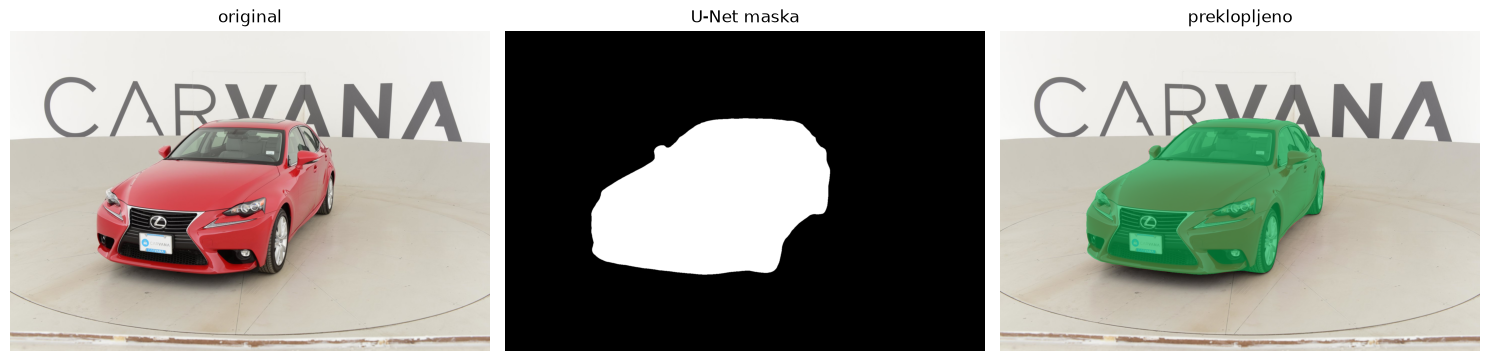

objekat zauzima 18.3% slike


In [73]:
car_path = fetch("car.jpg", "https://raw.githubusercontent.com/ternaus/TernausNet/master/lexus.jpg")
car = np.array(Image.open(car_path).convert("RGB"))

mask = segment(car)
overlay = car.copy()
overlay[mask>0] = (overlay[mask>0]*0.4 + np.array([0,180,80])*0.6).astype(np.uint8)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].imshow(car);     ax[0].set_title("original");    ax[0].axis("off")
ax[1].imshow(mask, cmap="gray"); ax[1].set_title("U-Net maska"); ax[1].axis("off")
ax[2].imshow(overlay); ax[2].set_title("preklopljeno"); ax[2].axis("off")
plt.tight_layout(); plt.show()
print("objekat zauzima %.1f%% slike" % (100*(mask>0).mean()))

<p>Maska precizno prati konturu automobila, uključujući fine detalje (ivice, ogledala). Upravo ovakav izlaz (<b>piksel-po-piksel maska</b>) čini U-Net pogodnim za segmentaciju lezija: kad se lezija izdvoji, klasifikator dalje „gleda” samo nju, bez okolne kože, dlaka i pozadine.</p>

<h2>12.2 Segmentacija kao korak predobrade</h2>

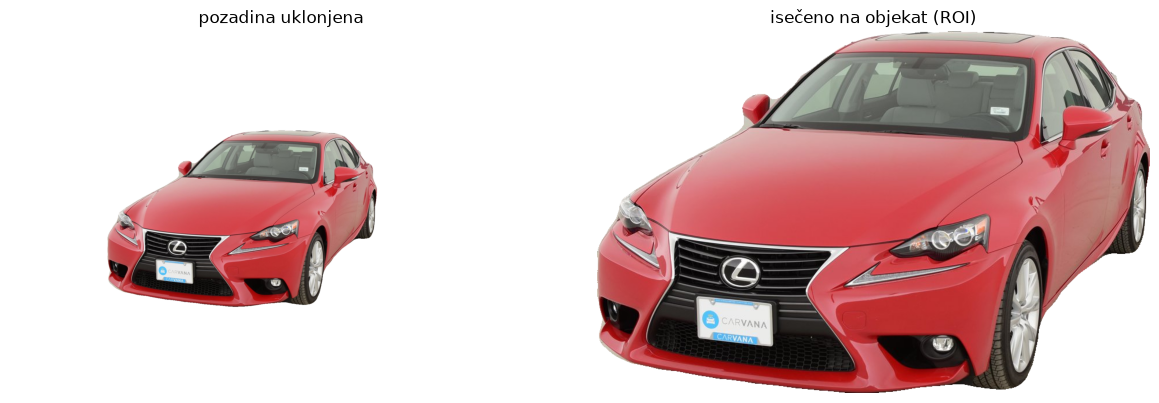

In [ ]:
masked = car.copy(); masked[mask==0] = 255
crop = car.copy()
ys, xs = np.where(mask>0)
if len(xs):
    y0,y1,x0,x1 = ys.min(), ys.max(), xs.min(), xs.max()
    crop = masked[y0:y1, x0:x1]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(masked); ax[0].set_title("pozadina uklonjena"); ax[0].axis("off")
ax[1].imshow(crop);   ax[1].set_title("isečeno na objekat (ROI)"); ax[1].axis("off")
plt.tight_layout(); plt.show()

<p>Segmentacija + maskiranje + isecanje na region interesa (ROI) tipičan je pretprocesni lanac: klasifikatoru se prosleđuje samo objekat, čime se uklanja irelevantan kontekst i smanjuje šansa da model nauči pogrešne obrasce (npr. pozadinu umesto lezije).</p>

<h3>Analiza: kombinovani pipeline</h3>
<ul>
<li><b>augment</b> i <b>augment + class_weight</b>: oba daju isti SVM rezultat (balanced accuracy 0.4268, macro-F1 0.4078), što je najveći skok u odnosu na baseline (+0.1355). Dodavanje class_weight na već balansirani skup ne donosi dodatnu korist za SVM.</li>
<li><b>CLAHE + augment</b> i <b>CLAHE + augment + class_weight</b>: CLAHE je <b>pogoršao</b> rezultat: balanced accuracy pada na 0.2785, ispod baseline-a. Na 28×28 pikselima adaptivno izjednačavanje histograma iskrivljuje vrednosti piksela na kojima SVM direktno radi, što anulira dobit od balansiranja.</li>
</ul>
<p>Zaključak: <b>plain oversample augmentacija</b> je pobednički pipeline. CLAHE je koristan na punoj rezoluciji (sekcija 7.2) i uz CNN-ove, ali šteti SVM-u na ovako malim slikama — dobar primer da predobrada mora da odgovara i modelu i rezoluciji, a ne samo skupu.</p>

# 11 Zaključak

In [75]:
full = pd.DataFrame(results)
full

,experiment,technique,model,accuracy,balanced_acc,macro_f1,fit_s
0,clean,baseline,SVM,0.7333,0.2913,0.3145,0.23
1,clean,baseline,k-NN,0.6800,0.2173,0.2175,0.00
2,clean,gaussian noise,SVM,0.6880,0.1886,0.1913,0.48
3,clean,gaussian noise,k-NN,0.6693,0.2292,0.2355,0.00
4,clean,noise + gauss filter,SVM,0.7173,0.2837,0.3092,0.38
5,clean,noise + gauss filter,k-NN,0.6907,0.2577,0.2608,0.00
6,clean,salt&pepper noise,SVM,0.6853,0.2110,0.2203,0.40
7,clean,salt&pepper noise,k-NN,0.6693,0.2061,0.1999,0.00
8,clean,s&p + median filter,SVM,0.7253,0.2815,0.2988,0.22
9,clean,s&p + median filter,k-NN,0.6693,0.2357,0.2385,0.00


<h2>Zaključci</h2>

<p><b>Šta je dalo najbolje rezultate:</b></p>
<ul>
<li><b>Augmentacija (oversample)</b> - SVM balanced accuracy 0.43, macro-F1 0.41; jedina tehnika koja značajno podiže učinak na retkim klasama</li>
<li><b>Medijan filter</b> nakon so-i-biber šuma - gotovo potpun oporavak, macro-F1 pao samo za 0.016 vs. baseline</li>
<li><b>Min-max normalizacija</b> - neutrališe varijacije između uređaja; bez nje device variation obara macro-F1 za 0.12</li>
</ul>

<p><b>Šta je dalo najgore rezultate:</b></p>
<ul>
<li><b>Gaussov šum</b> - najveći pad, SVM macro-F1 0.19 (−0.12 vs. baseline); 28×28 slike nemaju dovoljno susednih piksela da filtar efektno ukloni šum</li>
<li><b>CLAHE</b> - macro-F1 0.20, ispod baseline-a; na 28×28 pojačava artefakte umesto strukture lezije, na punoj rezoluciji radi dobro</li>
<li><b>Blur</b> - trajno briše ivice bez oporavka; bolje odbaciti zamućene snimke nego ih ispravljati</li>
</ul>

<p><b>Opšti zaključak:</b></p>
<ul>
<li>Tačnost (accuracy) vara na neuravnoteženom skupu - ~67% postiže i trivijalni klasifikator koji uvek predviđa <code>nv</code></li>
<li>Pravu sliku daju balanced accuracy i macro-F1</li>
<li>Predobrada nije univerzalno dobra - mora odgovarati i modelu i rezoluciji slike</li>
</ul>